# Experiment 6: is prominence embedder-invariant? (the deciding test)

Notebook 5 left one claim unproven: prominence ranks boundaries best (92% vs 67% for the floor on the synthetic passage), and it *should* be invariant to the embedder because peak prominence is a height *difference*, so shifting or scaling `d` (which is what swapping embedders does) cancels out. The floor, a fixed absolute threshold on `d`, should not survive a scale change. This notebook tests both.

**Method.** Re-run the same ranking analysis under a second, differently-scaled embedder and see what moves.

- Synthetic passage (English): the production **Qwen3-Embedding-4B** (anisotropic, high-baseline cosines) vs **all-MiniLM-L6-v2** (384-dim, low and spread cosines). Two very different scales.
- KPC statute (Polish): Qwen3 vs **mmlw-retrieval-roberta-large**, a Polish model, so the contrast is on real target text in its own language.

**What each outcome means.**

- If prominence's *matched-budget recall* holds across embedders while the floor's *shipped* behaviour (how much `0.6` cuts, and its recall) swings, the shape feature is the embedder-invariant detector and the case for replacing the floor is closed.
- If prominence also swings, the invariance argument fails and we keep looking.

Same trusted boundaries and same +/-1 tolerance as notebook 5.

In [1]:
from pathlib import Path
import re

import fitz
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.signal import find_peaks
from scipy.stats import median_abs_deviation

from text_change_detector.shared.embedder import SentenceTransformerEmbedder
from text_change_detector.tiling import pipeline
from text_change_detector.tiling.extraction.pdf import extract_pdf
from text_change_detector.tiling.extraction.shared import load_nlp

RADIUS = 15
WINDOW = 4
TOL = 1
FLOOR_D = 1.0 - 0.6
Z_SHIP = 3.0
QWEN = 'Qwen/Qwen3-Embedding-4B'
MINI = 'all-MiniLM-L6-v2'
MMLW = 'sdadas/mmlw-retrieval-roberta-large'
C_FLOOR = '#c0392b'
C_Z = '#e08a1e'
C_PROM = '#2e86c1'

/home/marek/repos/priv/text_change_detector/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def pick_device():
    if torch.cuda.is_available() and torch.cuda.mem_get_info()[0] > 9 * 1024 ** 3:
        return 'cuda'

    return 'cpu'


DEVICE = pick_device()

print('device:', DEVICE)

device: cuda


## The detectors and metric (same as notebook 5)

Scores per gap: floor = `d`, z-score = local robust z (radius 15), prominence = peak prominence. `matched_recall` gives each method exactly `#boundaries` cuts (top-scored) and measures ranking alone; `shipped_cut` applies each method's default threshold.

In [3]:
def local_z(d, radius=RADIUS):
    n = len(d)
    z = np.full(n, -np.inf)

    for k in range(n):
        lo = max(0, k - radius)
        hi = min(n, k + radius + 1)
        local = d[lo:hi]
        s = median_abs_deviation(local, scale='normal')

        if s > 0:
            z[k] = (d[k] - np.median(local)) / s

    return z


def prominence(d):
    prom = np.zeros(len(d))
    peaks, props = find_peaks(d, prominence=0)
    prom[peaks] = props['prominences']

    return prom


def scores(d):
    return {'floor': d, 'z-score': local_z(d), 'prominence': prominence(d)}


def recall_at(pred, gt, tol=TOL):
    pred = set(pred)

    return sum(any(abs(g - p) <= tol for p in pred) for g in gt) / len(gt)


def matched_recall(score, gt, region):
    top = sorted(region, key=lambda g: score[g], reverse=True)[:len(gt)]

    return recall_at(top, gt)


def shipped_cut(name, score, region):
    if name == 'floor':
        return [g for g in region if score[g] >= FLOOR_D]
    if name == 'z-score':
        return [g for g in region if score[g] >= Z_SHIP]

    peaks = score[[g for g in region if score[g] > 0]]
    cutoff = peaks.mean() - 0.5 * peaks.std() if len(peaks) else 0.0

    return [g for g in region if score[g] > 0 and score[g] >= cutoff]

## Datasets and trusted boundaries

In [4]:
SYN = [
    'The city library lends books to any resident who holds a valid membership card.',
    'A new member registers at the front desk by presenting a photo ID and proof of address.',
    'The librarian then issues a card that is valid for three years from the date of registration.',
    'Each member may borrow up to ten books at a time.',
    'The standard loan period for a book is twenty-one days.',
    'A member can check the due date printed on the receipt handed out at the counter.',
    'Borrowed books may be renewed twice if no other reader has reserved them.',
    'A renewal extends the loan by a further twenty-one days from the day it is granted.',
    "Members renew a book either at the desk or through the library's online catalogue.",
    'When a title is already on loan, a member may place a reservation on it.',
    'The system notifies the member by email as soon as a reserved book is returned.',
    'A reserved book is then held at the pickup shelf for seven days.',
    'If the member does not collect it within that week, the reservation is cancelled.',
    "Returning a book on time keeps the member's account in good standing.",
    'A book returned after its due date incurs a fine of twenty cents per day.',
    'The fine stops accruing once the outstanding balance reaches ten euros for a single title.',
    'Members can pay their fines at the desk or online through the member portal.',
    'An account with unpaid fines above five euros is blocked from further borrowing.',
    'The block is lifted automatically the moment the balance falls back below that limit.',
    'Books may be returned to the front desk during opening hours.',
    'Outside opening hours, members drop books into the return bin beside the main entrance.',
    'Staff empty the return bin every morning and check each book back into the system.',
    'A book is only counted as returned once staff have scanned it at the desk.',
    'Damaged books are set aside for the repair team to assess.',
    'A member who returns a badly damaged book may be charged its replacement cost.',
    'Lost books are billed at the replacement cost plus a small processing fee.',
    'Reference books and rare editions are marked as non-circulating and cannot be borrowed.',
    'These titles may only be consulted inside the reading room.',
    "Children under twelve borrow on a junior card linked to a parent's account.",
    'The junior card carries a lower borrowing limit of five books at a time.',
    'Audiobooks and DVDs follow the same loan period as printed books.',
    'However, DVDs may not be renewed and must be returned within the first loan period.',
    'Members can browse the full catalogue from home using their card number and a PIN.',
    'The online catalogue shows whether each copy is available, on loan, or reserved.',
    'A member who forgets their PIN can reset it by confirming their email address.',
    'The library sends a courtesy reminder three days before any book falls due.',
    'A second reminder follows on the morning after a book becomes overdue.',
    'Members who prefer paper notices can opt out of email reminders at the desk.',
    'All borrowing history is kept private and is visible only to the member and staff.',
    'Members may ask staff to erase their past borrowing records at any time.',
]
SYN_GT = [2, 5, 8, 12, 18, 22, 25, 27, 29, 31, 34, 37]
PDF = next(p for p in [Path('data/DU_2023_1550_KPC.pdf'),
                       Path('experiments/data/DU_2023_1550_KPC.pdf')] if p.exists())
src = fitz.open(PDF)
fragment = fitz.open()

fragment.insert_pdf(src, from_page=0, to_page=49)

nlp = load_nlp('pl_core_news_sm')
kpc_segments = extract_pdf(fragment, nlp)
kpc_sents = [s.text for s in kpc_segments]
art = re.compile(r'^\s*Art\.\s*\d+')
KPC_GT = sorted({i - 1 for i in range(len(kpc_segments)) if art.match(kpc_segments[i].text) and i > 0})
region_start = min(KPC_GT)

print(f'synthetic: {len(SYN)} sentences, {len(SYN_GT)} boundaries')
print(f'KPC      : {len(kpc_sents)} segments, {len(KPC_GT)} article boundaries (region from gap {region_start})')

synthetic: 40 sentences, 12 boundaries
KPC      : 1001 segments, 26 article boundaries (region from gap 158)


## Embed under each model

Each embedder is loaded, used to build `d`, then freed before the next (they do not fit on one GPU together). Qwen3 covers both datasets; MiniLM embeds the English synthetic; the Polish mmlw embeds the Polish statute. mmlw is a retrieval model; we use it without its query prefix, which is fine for a scale comparison of sentence cosines.

In [5]:
def all_d(model_name, dtype, datasets):
    e = SentenceTransformerEmbedder(model_name=model_name, device=DEVICE, dtype=dtype, batch_size=8)
    out = {k: pipeline._step_dissimilarities(v, e, WINDOW) for k, v in datasets.items()}
    e.close()

    return out


qwen = all_d(QWEN, torch.float16, {'syn': SYN, 'kpc': kpc_sents})
mini = all_d(MINI, None, {'syn': SYN})
mmlw = all_d(MMLW, None, {'kpc': kpc_sents})
D = {
    ('synthetic', 'Qwen3-4B'): (qwen['syn'], SYN_GT, list(range(len(SYN) - 1))),
    ('synthetic', 'MiniLM-L6'): (mini['syn'], SYN_GT, list(range(len(SYN) - 1))),
    ('KPC', 'Qwen3-4B'): (qwen['kpc'], KPC_GT, list(range(region_start, len(kpc_sents) - 1))),
    ('KPC', 'mmlw-PL'): (mmlw['kpc'], KPC_GT, list(range(region_start, len(kpc_sents) - 1))),
}

print('embedded:', [f'{a}/{b}' for a, b in D])

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:  20%|██        | 81/398 [00:00<00:00, 788.02it/s]

Loading weights:  42%|████▏     | 168/398 [00:00<00:00, 835.30it/s]

Loading weights:  65%|██████▍   | 257/398 [00:00<00:00, 837.54it/s]

Loading weights:  86%|████████▌ | 341/398 [00:00<00:00, 831.64it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 15288.18it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 4016.88it/s]

embedded: ['synthetic/Qwen3-4B', 'synthetic/MiniLM-L6', 'KPC/Qwen3-4B', 'KPC/mmlw-PL']


## The scale shift is real

Distribution of the window similarity `1 - d` under each embedder, with the floor line at 0.6. If the two models put their typical similarity in different places, the same `0.6` means different things, which is the whole fragility of an absolute threshold.

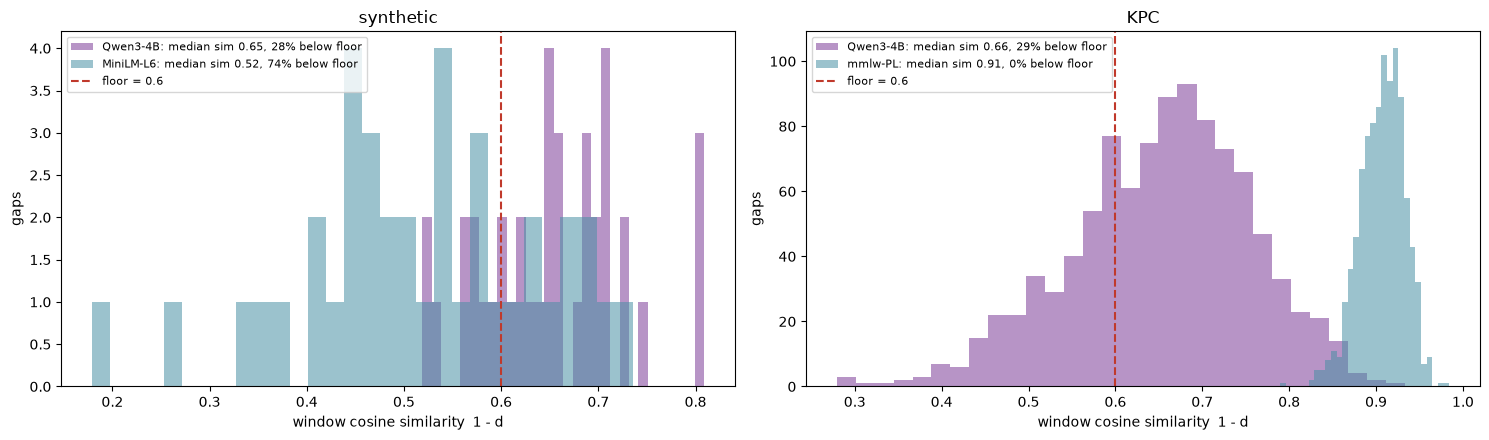

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
pairs = [('synthetic', ['Qwen3-4B', 'MiniLM-L6']), ('KPC', ['Qwen3-4B', 'mmlw-PL'])]
cols = {'Qwen3-4B': '#7d3c98', 'MiniLM-L6': '#4a90a4', 'mmlw-PL': '#4a90a4'}

for ax, (ds, models) in zip(axes, pairs):
    for m in models:
        d = D[(ds, m)][0]
        sim = 1.0 - d

        ax.hist(sim, bins=30, alpha=0.55, color=cols[m],
                label=f'{m}: median sim {np.median(sim):.2f}, {np.mean(sim <= 0.6):.0%} below floor')

    ax.axvline(0.6, color=C_FLOOR, linestyle='--', linewidth=1.5, label='floor = 0.6')
    ax.set_xlabel('window cosine similarity  1 - d')
    ax.set_ylabel('gaps')
    ax.set_title(ds)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## The deciding numbers

For each dataset and embedder: the **matched-budget recall** of each method (ranking quality, threshold-free), and the **floor's shipped behaviour** at `0.6` (how many gaps it cuts and its recall). Invariance shows up as prominence's matched-budget recall staying put across the two embedders, while the floor's cut count moves.

In [7]:
def line(ds, model):
    d, gt, region = D[(ds, model)]
    sc = scores(d)
    mb = {m: matched_recall(sc[m], gt, region) for m in ['floor', 'z-score', 'prominence']}
    fcut = shipped_cut('floor', sc['floor'], region)
    pcut = shipped_cut('prominence', sc['prominence'], region)

    return mb, len(fcut), recall_at(fcut, gt), len(pcut), recall_at(pcut, gt)


print(f'{"dataset":10s} {"embedder":11s} | {"matched-budget recall":27s} | {"floor@0.6":16s} {"prom@Hearst":s}')
print(f'{"":10s} {"":11s} | {"floor":>7s} {"z-score":>8s} {"prom":>8s} | {"cuts":>5s} {"recall":>7s}  {"cuts":>5s} {"recall":>7s}')
print('-' * 92)

for ds, model in D:
    mb, fc, fr, pc, pr = line(ds, model)

    print(f'{ds:10s} {model:11s} | {mb["floor"]:6.0%} {mb["z-score"]:8.0%} {mb["prominence"]:8.0%} | '
          f'{fc:5d} {fr:7.0%}  {pc:5d} {pr:7.0%}')

dataset    embedder    | matched-budget recall       | floor@0.6        prom@Hearst
                       |   floor  z-score     prom |  cuts  recall   cuts  recall
--------------------------------------------------------------------------------------------
synthetic  Qwen3-4B    |    67%      75%      92% |    11     67%      5     42%
synthetic  MiniLM-L6   |    75%      67%      83% |    29     92%      8     58%
KPC        Qwen3-4B    |     8%       8%      12% |   232     50%    125     42%


KPC        mmlw-PL     |     0%       8%       4% |     0      0%    132     42%


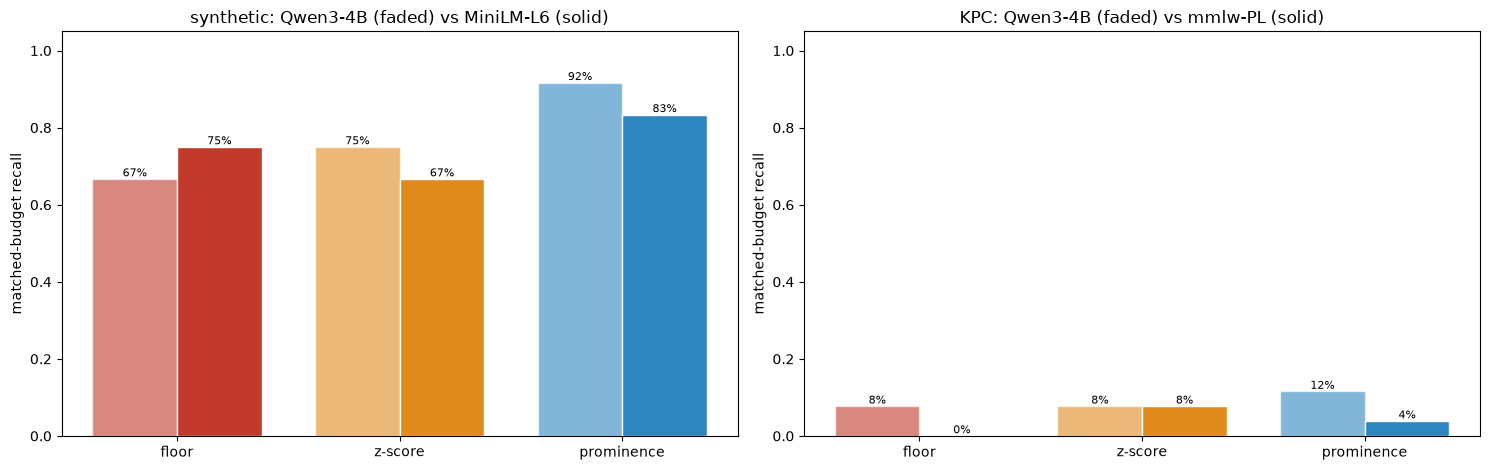

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
methods = ['floor', 'z-score', 'prominence']
mcol = [C_FLOOR, C_Z, C_PROM]

for ax, (ds, models) in zip(axes, pairs):
    x = np.arange(len(methods))
    w = 0.38

    for j, m in enumerate(models):
        d, gt, region = D[(ds, m)]
        sc = scores(d)
        vals = [matched_recall(sc[mm], gt, region) for mm in methods]
        bars = ax.bar(x + (j - 0.5) * w, vals, w, label=m,
                      color=[mcol[i] for i in range(len(methods))],
                      alpha=0.6 if j == 0 else 1.0, edgecolor='white')

        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.0%}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel('matched-budget recall')
    ax.set_title(f'{ds}: {models[0]} (faded) vs {models[1]} (solid)')
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## Observations

**Verdict. The test is decisive. The floor's absolute `0.6` does not transfer across embedders at all, while prominence does. The identical floor threshold produces anywhere from zero cuts to heavy over-segmentation depending only on the model. Prominence stays the best ranker on both embedders and its self-derived cutoff yields near-identical segmentation across models.**

**The floor is a per-embedder accident.** The same `0.6` cuts, over the same text:

| | floor@0.6 cuts | of total |
|---|---|---|
| synthetic, Qwen3-4B | 11 | 39 |
| synthetic, MiniLM-L6 | 29 | 39 |
| KPC, Qwen3-4B | 232 | 842 |
| KPC, mmlw-PL | **0** | 842 |

On MiniLM the floor cuts 74% of the synthetic gaps (near everything) where on Qwen it cuts 28%. On the Polish mmlw it cuts **nothing at all**, because that model's cosines sit so high that `d` never reaches `0.4`: the shipped pipeline would return no segmentation whatsoever on a model swap, silently. A single hardcoded constant cannot span that range. This is the concern from notebook 3 proven at its strongest.

**Prominence transfers, on both axes.** As a *ranker* it is the best of the three on both embedders for the clean case: matched-budget recall **92% (Qwen) and 83% (MiniLM)**, versus the floor's 67% / 75% and the z-score's 75% / 67%. It drops 9 points across the scale change, so it is robust rather than perfectly constant, but it stays on top. And its *cutoff* transfers where the floor's does not: `prom@Hearst` cuts **125 gaps on Qwen and 132 on mmlw** on KPC, at **42% recall under both**, exactly where `floor@0.6` gave 232 cuts / 50% on one model and 0 cuts / 0% on the other. A shape-relative cutoff lands in the same place on two very different embedders; the absolute floor swings from nothing to everything.

**The domain limit is embedder-independent.** On KPC the matched-budget recall is weak for every method under both embedders (prominence 12% / 4%, floor 8% / 0%). Swapping to a Polish model does not rescue it. This reconfirms notebook 5: dissimilarity, from any of these embedders, barely tracks article structure in a statute, because consecutive articles share the same register. The signal, not the embedder, is the ceiling there.

**Caveats.** Two embedders per dataset, not a sweep. mmlw is a retrieval model used without its query prefix, which may lift its baseline similarity further (and is part of why the floor sees nothing). The KPC numbers inherit the article-boundary caveats from notebook 5. None of this touches the core result, which rests on the floor's cut count ranging over `{0, 11, 29, 232}` for one fixed threshold.

**Decision.** For general-purpose segmentation the direction is now settled: **replace the absolute floor (and the redundant z-score) with a depth / prominence detector whose cutoff is derived from the signal.** It is the better ranker and, unlike `0.6`, it survives an embedder swap instead of silently collapsing to no-segmentation or all-segmentation. The remaining knob (Hearst's `c`) lives on a scale-relative shape distribution, which is the acceptable kind of parameter. Separately, and unchanged by this notebook, statutes need a structural lever (feeding the `Art. N.` markers as boundary priors): no dissimilarity detector, on any embedder tested, gets past ~50% recall of article boundaries.